# Grundläggande analys och statistik

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from scipy import stats
from statsmodels.stats.power import TTestIndPower

data_set = pd.read_csv("data/health_study_dataset.csv")

In [2]:
display(data_set.describe().round(2))
display(data_set.info())

,id,age,height,weight,systolic_bp,cholesterol,disease
count,800.00,800.00,800.00,800.00,800.00,800.00,800.00
mean,400.50,49.43,171.85,73.41,149.18,4.93,0.06
std,231.08,14.50,9.80,13.69,12.79,0.85,0.24
min,1.00,18.00,144.40,33.70,106.80,2.50,0.00
25%,200.75,39.00,164.78,64.80,140.90,4.33,0.00
50%,400.50,50.00,171.35,73.20,149.40,4.97,0.00
75%,600.25,59.00,178.92,82.60,157.60,5.48,0.00
max,800.00,90.00,200.40,114.40,185.90,7.88,1.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           800 non-null    int64  
 1   age          800 non-null    int64  
 2   sex          800 non-null    object 
 3   height       800 non-null    float64
 4   weight       800 non-null    float64
 5   systolic_bp  800 non-null    float64
 6   cholesterol  800 non-null    float64
 7   smoker       800 non-null    object 
 8   disease      800 non-null    int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 56.4+ KB


None

**Mean, median, min och max for: age, weight, height, systolic blood pressure, cholesterol**

In [3]:
data_summary =  (data_set[["age", "weight", "height", "systolic_bp", "cholesterol"]]
                 .agg(["mean", "median", "min", "max"])
                 .round(2)
                 )

display(data_summary)

,age,weight,height,systolic_bp,cholesterol
mean,49.43,73.41,171.85,149.18,4.93
median,50.00,73.20,171.35,149.40,4.97
min,18.00,33.70,144.40,106.80,2.50
max,90.00,114.40,200.40,185.90,7.88


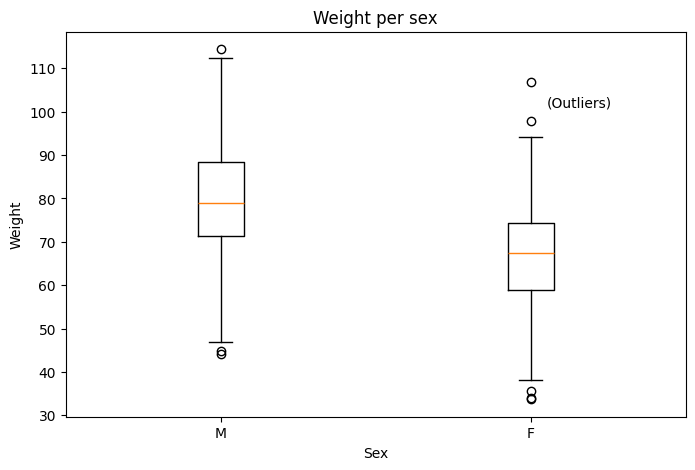

In [4]:
fig, ax = plt.subplots(figsize=(8,5))

ax.boxplot([data_set.loc[data_set["sex"] == "M", "weight"], 
            data_set.loc[data_set["sex"] == "F", "weight"]], 
            tick_labels=["M", "F"]
            )
ax.set_xlabel("Sex")
ax.set_ylabel("Weight")
ax.set_title("Weight per sex")
ax.annotate("(Outliers)", (2.05,101))
plt.tight_layout
plt.show()

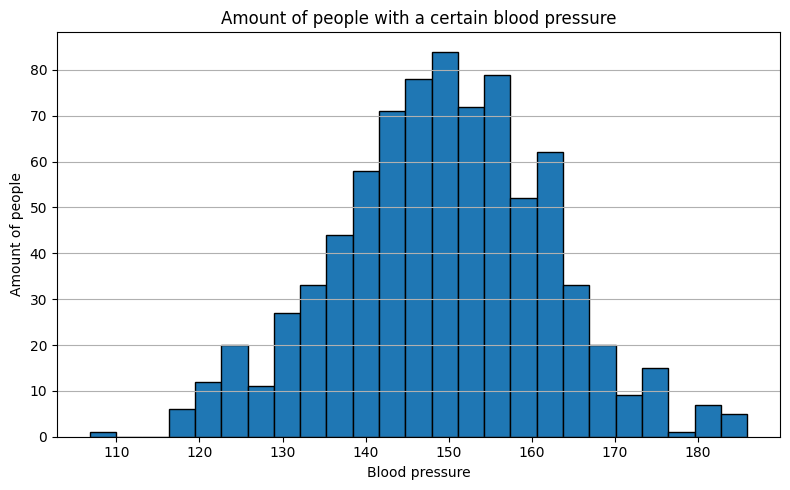

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(data_set["systolic_bp"], bins = 25, edgecolor="black")
ax.set_title("Amount of people with a certain blood pressure")
ax.set_xlabel("Blood pressure")
ax.set_ylabel("Amount of people")
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()

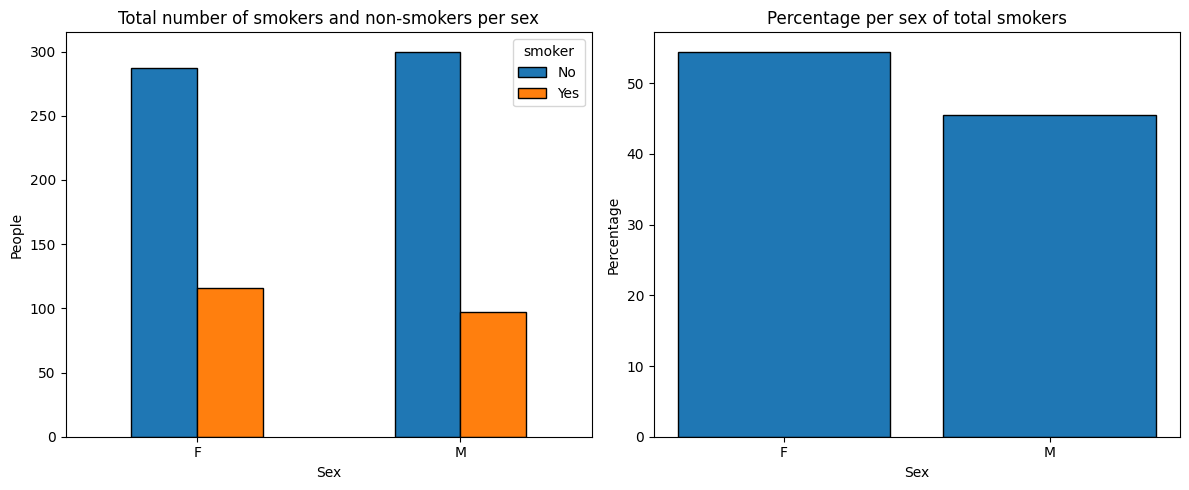

In [6]:
data_smokers_by_sex =  pd.crosstab(data_set["sex"], data_set["smoker"])
data_total_smokers = data_set[data_set["smoker"] == "Yes"]["sex"].value_counts(normalize=True)*100


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)
ax = axes[0]
data_smokers_by_sex.plot(kind="bar", edgecolor="black", ax=ax)
ax.set_title("Total number of smokers and non-smokers per sex")
ax.set_xlabel("Sex")
ax.set_ylabel("People")
ax.set_xticklabels(data_total_smokers.index, rotation=0)


axes[1].bar(data_total_smokers.index, data_total_smokers, edgecolor="black")
axes[1].set_title("Percentage per sex of total smokers")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Percentage")
plt.tight_layout()
plt.show()


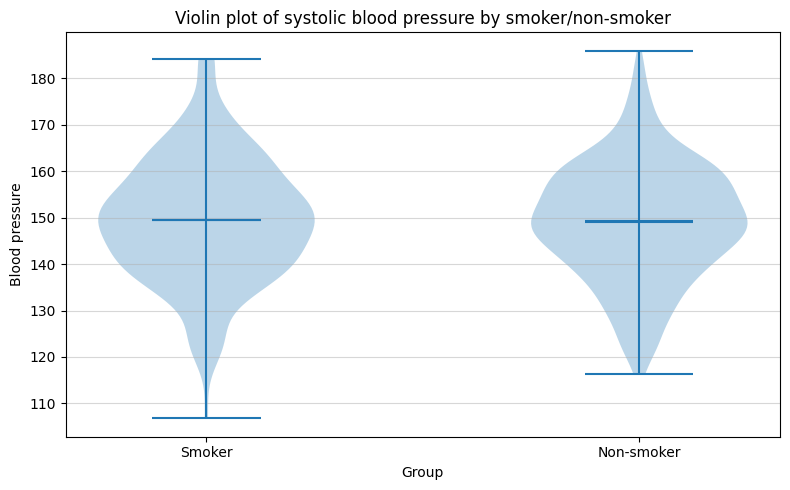

In [7]:
fig, ax = plt.subplots(figsize=(8,5))
ax.violinplot([data_set.loc[data_set["smoker"] == "Yes", "systolic_bp"], 
               data_set.loc[data_set["smoker"] == "No", "systolic_bp"]], 
               showmeans=True, showmedians=True
               )
ax.set_title("Violin plot of systolic blood pressure by smoker/non-smoker")
ax.set_xlabel("Group")
ax.set_xticks([1, 2])
ax.set_xticklabels(["Smoker", "Non-smoker"])
ax.set_ylabel("Blood pressure")
ax.grid(True, axis="y", alpha=0.5)
plt.tight_layout()
plt.show()

In [8]:
disease_amount = data_set["disease"].mean()

# Simulate number of disease with the same percentage as observed.
np.random.seed(42)
n=1000
disease_simulated = np.random.choice([1, 0], p=[disease_amount, 1-disease_amount], size=n)          # Randomizes values 1 and 0 with the same % as observed.
disease_simulated_percentage = disease_simulated.mean()
print(f"{disease_amount*100:.3f}% of the people in the health study has the disease.")
print(f"Randomized number of disease per {n} people with the same percentage as observed({disease_amount*100:.3f}%) gives {disease_simulated_percentage*100:.3f}%.")

# Compare results.
if disease_simulated_percentage > disease_amount:
    print(f"Simulated percentage is {(disease_simulated_percentage - disease_amount)*100:.3f}% larger than observed.")
elif disease_simulated_percentage < disease_amount:
    print(f"Simulated percentage is {abs(disease_simulated_percentage - disease_amount)*100:.3f}% smaller than observed.")
else:
    print("There is no difference between the simulated and observed percentage.")

5.875% of the people in the health study has the disease.
Randomized number of disease per 1000 people with the same percentage as observed(5.875%) gives 6.300%.
Simulated percentage is 0.425% larger than observed.


**Confidence interval of mean of systolic blood pressure.**

In [9]:
# Confidence interval using the normal approximation method.
n = len(data_set["systolic_bp"])
s = data_set["systolic_bp"].std()
mean_x = data_set["systolic_bp"].mean()
z = 1.96
se = s / np.sqrt(n)

low = mean_x - z * se
high = mean_x + z * se

print(f"Mean: {mean_x:.2f}")
print(f"Standard deviation: {s:.2f}")
print(f"Standard error: {se:.2f}")
print(f"Normal approximation 95% CI: {low:.2f}, {high:.2f}")

# Confidence interval using the bootstrap method.
confidence = 0.95
B = 10000
boot_x = data_set["systolic_bp"]
boot_n = len(boot_x)
boot_means = np.empty(B)

for b in range(B):
    boot_sample = np.random.choice(boot_x, size=boot_n, replace=True)
    boot_means[b] = np.mean(boot_sample)

alpha = (1 - confidence) / 2
boot_lo, boot_hi = np.percentile(boot_means, [100*alpha, 100*(1-alpha)])

print(f"\nBootstrap 95% CI: {boot_lo:.2f}, {boot_hi:.2f}")
print(f"Difference in CI between the two methods: lower={(boot_lo - low):.3f}, upper = {(boot_hi - high):.3f}")


Mean: 149.18
Standard deviation: 12.79
Standard error: 0.45
Normal approximation 95% CI: 148.29, 150.07

Bootstrap 95% CI: 148.31, 150.07
Difference in CI between the two methods: lower=0.015, upper = 0.009


Comparing these two methods, normal approximation and bootstrap, shows similar results regarding CI-values. This tells us that normal approximation is sufficient for this study. Bootstrap is generally more reliable with smaller samples and does not rely on assumptions about the data, it can improve accuracy through resampling. However, seeing the results are almost identical, they both produce values that are reliable for this study, but using both strengthens the result.

External source: https://www.geeksforgeeks.org/maths/bootstrap-method/

**Hypothesis test: smokers have higher mean blood pressure than non-smokers.**

For the test I've chosen to use a Welch t-test. The reasons being that we compare two groups of unequal sample size, but with sufficiently large sample sizes to not need a bootstrap test. 

In [10]:
# Welch T-test
smokers_bp = data_set[data_set["smoker"] == "Yes"]["systolic_bp"]
nonsmokers_bp = data_set[data_set["smoker"] == "No"]["systolic_bp"]

t_stat, p_val = stats.ttest_ind(smokers_bp, nonsmokers_bp, equal_var=False)

print(f"Mean for smokers: {smokers_bp.mean():.3f}")
print(f"Mean for non-smokers: {nonsmokers_bp.mean():.3f}")
print(f"Standard t-test: t = {t_stat:.3f}, p = {p_val:.3f}")


Mean for smokers: 149.525
Mean for non-smokers: 149.053
Standard t-test: t = 0.450, p = 0.653


A welch t-test value of 0.45 is a value close to 0, which indicates there's no reliable statistical difference between the groups. Paired with a large p-value of 0.645, which means 65.3% of the time a random sample would produce a difference this big or bigger if there were no differences between groups. The welch t-test shows no statistically significant difference between smokers and non-smokers when it comes to systolic blood pressure.

External source: https://www.geeksforgeeks.org/r-language/running-two-sample-t-test-with-unequal-sample-size-in-r/

**Testing the power of my t-test.**

In [11]:
from statsmodels.stats.power import TTestIndPower

mean_smokers = smokers_bp.mean()
mean_non = nonsmokers_bp.mean()
n_smokers = len(smokers_bp)
n_non = len(nonsmokers_bp)

sd_pooled = data_set["systolic_bp"].std()

cohen_d = (mean_smokers - mean_non) / sd_pooled

alpha = 0.05

ratio = n_smokers / n_non

power_T = TTestIndPower().power(
    effect_size=cohen_d,
    nobs1=n_non,
    alpha=alpha,
    ratio=ratio,
    alternative="two-sided"
)

n_needed_T = TTestIndPower().solve_power(
    effect_size=cohen_d,
    alpha=alpha,
    power=0.8,
    ratio=ratio,
    alternative="two-sided"
)

print(f"Power for the test to detect a difference: {power_T*100:.2f}%")
print(f"Sample size needed to reach a power of 80%: {n_needed_T:.0f} -- compared to the observed sample size of {len(data_set["smoker"])} people.")

Power for the test to detect a difference: 7.46%
Sample size needed to reach a power of 80%: 21668 -- compared to the observed sample size of 800 people.


Based on these results, the chance to detect a real difference is very low with the sample size we have. We would need a much larger sample size to be able to achieve the statistical power of 80% and be able to apply any statistical certainty to our results. With this data and all results in mind(normal aprox, bootstrap, welch t-test and power), there is no support for there being a significant difference between smokers and non-smokers regarding their systolic blood pressure.


Alexander Ahl